In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# TODO

- Clustering for further topic reduction
    - Agglomerative or via Bertopic itself??
- Repeat pipeline for competitors
    - mapping their topics onto main app becomes challenging

In [2]:
from google_play_scraper import app, search, reviews, reviews_all, Sort
import string
import matplotlib.pyplot as plt
import re

In [6]:
app_id = 'com.duolingo'

In [7]:
review_results = reviews(app_id, 
                         count=30000, 
                         lang='en', 
                         country='us')

print('reviews fetched')

review_df = pd.DataFrame(review_results[0])
review_df['n_words'] = review_df.content.str.split(' ').str.len()

reviews fetched


found that some non-english reviews were still being pulled in, therefore langdetect is used for further filtering

In [8]:
from langdetect import detect

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

review_df = review_df[review_df["content"].apply(is_english)]
print(len(review_df))

20368


filtering reviews based on length and removing positive reviews

In [9]:
review_df_filtered = review_df[(review_df.n_words >= 10) & 
    (review_df.score <= 3)]
review_texts = np.array(review_df_filtered.content)
review_texts = [str(t) for t in review_texts]

print(len(review_texts))

2451


## Building Custom Stopwords

While typical english stop words are useful there are domain specific words which are likely to occur in many reviews that do not inform anything that can be used to inform topics/themes.

Genre specific terms e.g. for learning apps ('lesson', 'learn', 'language') are manually set via a list. 

I tested various methods for deriving what these words could be: most common words in the app description. Using an LLM... Issues arose and I found that the best method (for now) is to just set these manually

In [10]:
#getting some app info
result = app(app_id)

In [11]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


def title_lemma_and_plural(x):
    name, text = re.split("[:-]", x)
    words = tokenize(text)
    new_words = []
    for word in words:
        if word[-1] == 's':
            new_words.append(word[:-1])
        else:
            new_words.append(word+'s')
    return [name.lower()] + words + new_words

GENERIC_APP_WORDS = [
    "app", "apps", "play", "game", "games", "really", "just", "also",
    "use", "using", "used", "get", "got", "im", "ive", "dont", "doesnt", 'install'
]

GENRE_ACTIVITY_WORDS = {
    "EDUCATION": ["learn", "learning", "study", "studying", 'lesson', 'lessons'],
    "HEALTH_AND_FITNESS": ["workout", 'workouts', "exercise", "train", "training"],
    "MUSIC_AND_AUDIO": ["listen", "listening", "play", "playing"],
    'DATING':['date']
}

custom_stopwords = list(set(
    title_lemma_and_plural(result['title']) + 
    GENRE_ACTIVITY_WORDS[result['genreId']] +
    GENERIC_APP_WORDS + 
    list(ENGLISH_STOP_WORDS)))

# Topic Modelling

In [12]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from hdbscan import HDBSCAN
from umap import UMAP
import math
from sentence_transformers import SentenceTransformer

#embeddings model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(review_texts, show_progress_bar=True)

vectorizer = CountVectorizer(stop_words=custom_stopwords, ngram_range=(1, 2), min_df=2)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 77/77 [00:36<00:00,  2.12it/s]


To automate we fit multiple times to find the settings which produce the least number of outliers

In [ ]:
def fit_until_stable(review_texts, embeddings, vectorizer, embedding_model,
                     target_min_topics=25, target_max_topics=50,
                     outlier_threshold=0.15, max_attempts=6):
    
    n_docs = len(review_texts)
    min_cluster_size = max(10, n_docs // 150)
    min_samples = 7        # keep this low — sweep showed this broke the cliff edge
    n_neighbors = 5        # sweep showed this gives lowest outliers
    prev_params = None
    for attempt in range(max_attempts):
        current_params = (min_cluster_size, min_samples, n_neighbors)
        
        if current_params == prev_params:
            print("Parameters unchanged — cannot improve further, stopping")
            break
        
        prev_params = current_params
        
        print(f"\nAttempt {attempt+1}: min_cluster_size={min_cluster_size}, "
                  f"min_samples={min_samples}, n_neighbors={n_neighbors}")

        umap_model = UMAP(
            n_neighbors=n_neighbors,
            n_components=5,
            min_dist=0.0,
            metric='cosine',
            random_state=42
        )
        hdbscan_model = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric='euclidean',
            cluster_selection_method='eom',
            prediction_data=True
        )
        topic_model = BERTopic(
            embedding_model=embedding_model,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer,
            min_topic_size=min_cluster_size,
            language='english',
            verbose=False
        )

        topics, probs = topic_model.fit_transform(review_texts, embeddings=embeddings)
        info = topic_model.get_topic_info()
        n_real_topics = len(info[info['Topic'] != -1])
        outlier_pct = info[info['Topic'] == -1]['Count'].values[0] / n_docs

        print(f"  → {n_real_topics} topics, {outlier_pct:.1%} outliers")

        if target_min_topics <= n_real_topics <= target_max_topics and outlier_pct < outlier_threshold:
            print("Stable result found")
            return topic_model, topics, probs

        # Topic count wrong — adjust min_cluster_size primarily
        if n_real_topics < target_min_topics:
            min_cluster_size = max(5, int(min_cluster_size * 0.8))
        elif n_real_topics > target_max_topics:
            min_cluster_size = int(min_cluster_size * 1.2)

        # Outlier rate wrong but topic count fine — only touch min_samples
        elif outlier_pct >= outlier_threshold:
            min_samples = max(3, int(min_samples * 0.8))

    print("Warning: did not converge, returning last result")
    return topic_model, topics, probs

topic_model, topics, probs = fit_until_stable(review_texts, embeddings, vectorizer, embedding_model)

print(topic_model.loc[-1, 'Count'])


Attempt 1: min_cluster_size=16, min_samples=7, n_neighbors=5
  → 43 topics, 21.4% outliers

Attempt 2: min_cluster_size=16, min_samples=5, n_neighbors=5
  → 47 topics, 22.6% outliers

Attempt 3: min_cluster_size=16, min_samples=4, n_neighbors=5
  → 49 topics, 16.5% outliers

Attempt 4: min_cluster_size=16, min_samples=3, n_neighbors=5
  → 50 topics, 15.8% outliers
Parameters unchanged — cannot improve further, stopping


we usually need to use the `reduce_outliers` function post

In [20]:
new_topics = topic_model.reduce_outliers(
    review_texts, topics,
    strategy="c-tf-idf"
)
topic_model.update_topics(review_texts, topics=new_topics, vectorizer_model=vectorizer)

topic_model.get_topic_info()


2026-06-25 14:12:39,879 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Topic,Count,Name,Representation,Representative_Docs
0,0,269,0_japanese_like_best_don,"[japanese, like, best, don, fun, time, think, ...","[Duolingo is a good app overall, with a fun an..."
1,1,244,1_ai_good_better_words,"[ai, good, better, words, way, don, japanese, ...",[Horrible AI voices. Sentences and teaching st...
2,2,115,2_hearts_energy_battery_heart,"[hearts, energy, battery, heart, gems, mistake...",[They changed the hearts to an energy bar and ...
3,3,95,3_speaking_pronunciation_say_sound,"[speaking, pronunciation, say, sound, speak, e...",[its fun for learning languages. i've scored i...
4,4,92,4_plan_free_family_subscription,"[plan, free, family, subscription, family plan...",[family plan stopped working. cant invite othe...
5,5,74,5_chess_win_playing chess_playing,"[chess, win, playing chess, playing, music, ch...",[Learning Japanese and Chess. It's getting on ...
6,6,76,6_love_good_easy_help,"[love, good, easy, help, adds, annoying, music...",[Love this perpetually evolving app. All the n...
7,7,66,7_icon_owl_looks_icons,"[icon, owl, looks, icons, home screen, home, d...",[Duolingo is a great app if you see. It teache...
8,8,57,8_trial_subscription_cancel_free trial,"[trial, subscription, cancel, free trial, refu...","[Charged me $168 for a year, the moment the fr..."
9,9,54,9_notifications_angry_reminders_face,"[notifications, angry, reminders, face, passiv...",[its a good app but i find the notification ex...


we have a lot of topics here so there's a lot more to do.

First step is to do further clusterings to reduce these.

We're going to do this after using Representation models. These are:
- LLM (Claude in this case; BERTopic has its own OpenAPI class which would be easier) 
- KeyBERT

## Representation Model: Using an LLM

In [23]:
import anthropic
from bertopic.representation._base import BaseRepresentation
from bertopic.representation._utils import truncate_document

class ClaudeRepresentation(BaseRepresentation):
    def __init__(self, client, model="claude-haiku-4-5-20251001", prompt=None,
                 nr_docs=4, diversity=None, doc_length=None, tokenizer=None):
        self.client = client
        self.model = model
        self.prompt = prompt or self.default_prompt()
        self.nr_docs = nr_docs
        self.diversity = diversity
        self.doc_length = doc_length
        self.tokenizer = tokenizer

    @staticmethod
    def default_prompt():
        return """I have a topic that contains the following documents:
            [DOCUMENTS]
            The topic is described by the following keywords: [KEYWORDS]
            
            Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Format:
            topic: <topic label>"""

    def extract_topics(self, topic_model, documents, c_tf_idf, topics):
        repr_docs_mappings, _, _, _ = topic_model._extract_representative_docs(
            c_tf_idf, documents, topics, nr_samples=500, nr_repr_docs=self.nr_docs
        )
        updated_topics = {}
        for topic, docs in repr_docs_mappings.items():
            keywords = ", ".join([w for w, _ in topics[topic]])
            doc_text = "\n".join(
                truncate_document(topic_model, self.doc_length, self.tokenizer, d)
                for d in docs
            )
            prompt = self.prompt.replace("[DOCUMENTS]", doc_text).replace("[KEYWORDS]", keywords)

            response = self.client.messages.create(
                model=self.model,
                max_tokens=50,
                messages=[{"role": "user", "content": prompt}]
            )
            label = response.content[0].text.strip()
            if label.lower().startswith("topic:"):
                label = label.split(":", 1)[1].strip()
            updated_topics[topic] = [(label, 1)] + topics[topic][1:]
        return updated_topics


anthropic_api_key = os.environ['ANTHROPIC_API_KEY']

client = anthropic.Anthropic(api_key=anthropic_api_key)

review_prompt = """I have a cluster of Google Play app reviews containing the following documents:
    [DOCUMENTS]
    The cluster is described by these keywords: [KEYWORDS]
    
    Extract a short, specific label (max 6 words) naming the concrete issue, feature, or sentiment these reviews share. Avoid vague labels like "general feedback". Format:
    topic: <label>
    """

claude_model = ClaudeRepresentation(client, model='claude-haiku-4-5-20251001', prompt=review_prompt)

In [24]:
from bertopic.representation import KeyBERTInspired

keybert_model = KeyBERTInspired()

In [25]:
representation_model = {
    'KeyBERT': keybert_model,
    'Claude': claude_model
}

topic_model.update_topics(review_texts, topics=new_topics, representation_model=representation_model, vectorizer_model=vectorizer)

info = topic_model.get_topic_info()

info

2026-06-25 14:16:42,899 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Topic,Count,Name,Representation,KeyBERT,Claude,Representative_Docs
0,0,269,0_japanese_like_best_don,"[japanese, like, best, don, fun, time, think, ...","[japanese, hiragana, english, teaches, basic, ...","[AI questions and lesson quality decline, like...","[Duolingo is a good app overall, with a fun an..."
1,1,244,1_ai_good_better_words,"[ai, good, better, words, way, don, japanese, ...","[ai voices, ai, voice, doesn teach, ai slop, t...","[AI voices degraded lesson quality, good, bett...",[Horrible AI voices. Sentences and teaching st...
2,2,115,2_hearts_energy_battery_heart,"[hearts, energy, battery, heart, gems, mistake...","[hearts energy, hearts, bring hearts, heart, e...","[Energy system replaced hearts feature, energy...",[They changed the hearts to an energy bar and ...
3,3,95,3_speaking_pronunciation_say_sound,"[speaking, pronunciation, say, sound, speak, e...","[speaking exercises, speaking tasks, speak, pr...","[Speaking exercise voice recognition issues, p...",[its fun for learning languages. i've scored i...
4,4,92,4_plan_free_family_subscription,"[plan, free, family, subscription, family plan...","[family plan, buying subscription, max plan, s...","[Family plan subscription billing misleading, ...",[family plan stopped working. cant invite othe...
5,5,74,5_chess_win_playing chess_playing,"[chess, win, playing chess, playing, music, ch...","[playing chess, chess, chess fun, chess chess,...","[Chess gameplay crashes and frustration, win, ...",[Learning Japanese and Chess. It's getting on ...
6,6,76,6_love_good_easy_help,"[love, good, easy, help, adds, annoying, music...","[beginners, teaches, educational, easy fun, te...",[Excessive gamification and interruptions disr...,[Love this perpetually evolving app. All the n...
7,7,66,7_icon_owl_looks_icons,"[icon, owl, looks, icons, home screen, home, d...","[icon annoying, annoying icon, icon looks, new...","[App icon changes causing user frustration, ow...",[Duolingo is a great app if you see. It teache...
8,8,57,8_trial_subscription_cancel_free trial,"[trial, subscription, cancel, free trial, refu...","[cancel subscription, free trial, cancelled su...","[Charged after canceling free trial, subscript...","[Charged me $168 for a year, the moment the fr..."
9,9,54,9_notifications_angry_reminders_face,"[notifications, angry, reminders, face, passiv...","[turn notifications, turned notifications, not...",[aggressive notification and guilt-trip tactic...,[its a good app but i find the notification ex...


Now with the representations we can use Agglomerative Clustering to reduce the number of topics

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

info['claude_label'] = info['Claude'].apply(
    lambda x: x[0][0] if isinstance(x[0], tuple) else str(x[0])
)

info['combined_rep'] = info.apply(
    lambda row: ' '.join([
        # Claude label
        row['claude_label'],
        # KeyBERT keywords for more surface vocabulary
        ' '.join([
            item[0] if isinstance(item, tuple) else str(item)
            for item in row['KeyBERT']
        ])
    ]),
    axis=1
)

topic_embeddings = embedding_model.encode(
    info['combined_rep'].tolist(),
    show_progress_bar=False
)

sim_matrix = cosine_similarity(topic_embeddings)


### Evaluating Thresholds

In [28]:
def evaluate_threshold(threshold, sim_matrix, info, review_texts, topics_array,
                       top_words, coherence_target=0.7):
    
    clusterer = AgglomerativeClustering(
        metric="precomputed",
        linkage="average",
        distance_threshold=threshold,
        n_clusters=None
    )
    labels = clusterer.fit_predict(1 - sim_matrix)
    topic_to_cluster = dict(zip(info['Topic'], labels))
    review_clusters = np.array([topic_to_cluster.get(t, -1) for t in topics_array])

    results = []
    for word in top_words:
        mask = np.array([word in text.lower() for text in review_texts])
        word_clusters = review_clusters[mask]
        word_clusters = word_clusters[word_clusters != -1]
        if len(word_clusters) < 5:
            continue
        dominant_cluster_count = np.bincount(word_clusters).max()
        coherence = dominant_cluster_count / len(word_clusters)
        results.append({
            'word': word,
            'n_reviews': len(word_clusters),
            'coherence': coherence,
            'passes': coherence >= coherence_target
        })

    results_df = pd.DataFrame(results)
    overall_pass_rate = results_df['passes'].mean()
    n_clusters = len(set(labels))

    print(f"threshold={threshold} → {n_clusters} clusters, "
          f"{results_df['passes'].sum()}/{len(results_df)} words pass "
          f"({overall_pass_rate:.1%})")

    return overall_pass_rate, n_clusters, results_df

In [29]:
def select_threshold(sim_matrix, info, thresholds=[0.3,0.35,0.4,0.45,0.5,0.55,0.6],
                     target_min=15, target_max=25):
    """
    Select lowest threshold that keeps cluster count in a sensible range.
    Avoids over-merging while still reducing redundant topics.
    """
    results = []
    for threshold in thresholds:
        clusterer = AgglomerativeClustering(
            metric="precomputed",
            linkage="average", 
            distance_threshold=threshold,
            n_clusters=None
        )
        labels = clusterer.fit_predict(1 - sim_matrix)
        n_clusters = len(set(labels))
        n_merges = len(info) - n_clusters
        results.append((threshold, n_clusters, n_merges))
        print(f"threshold={threshold} → {n_clusters} clusters, {n_merges} merges")
    
    # Pick lowest threshold within target range
    for threshold, n_clusters, n_merges in results:
        if target_min <= n_clusters <= target_max:
            print(f"\nSelected: threshold={threshold} → {n_clusters} clusters")
            return threshold
    
    # Fallback — closest to target range midpoint
    target_mid = (target_min + target_max) / 2
    best = min(results, key=lambda x: abs(x[1] - target_mid))
    print(f"\nFallback: threshold={best[0]} → {best[1]} clusters")
    return best[0]


In [30]:
# 1. Select threshold
selected_threshold = select_threshold(sim_matrix, info)

# 2. Get cluster labels at that threshold
clusterer = AgglomerativeClustering(
    metric="precomputed",
    linkage="average",
    distance_threshold=selected_threshold,
    n_clusters=None
)
labels = clusterer.fit_predict(1 - sim_matrix)
info['Cluster'] = labels

# 3. Extract only the groups that actually contain multiple topics
topics_to_merge = (
    info.groupby('Cluster')['Topic']
    .apply(list)
    .loc[lambda x: x.apply(len) > 1]  # only clusters with >1 topic
    .tolist()
)

print(f"Merging {len(topics_to_merge)} groups:")
for group in topics_to_merge:
    labels_in_group = info[info['Topic'].isin(group)]['claude_label'].tolist()
    print(f"  {group} → {' | '.join(labels_in_group)}")

threshold=0.3 → 44 clusters, 6 merges
threshold=0.35 → 38 clusters, 12 merges
threshold=0.4 → 36 clusters, 14 merges
threshold=0.45 → 34 clusters, 16 merges
threshold=0.5 → 29 clusters, 21 merges
threshold=0.55 → 26 clusters, 24 merges
threshold=0.6 → 24 clusters, 26 merges

Selected: threshold=0.6 → 24 clusters
Merging 10 groups:
  [0, 20, 21, 22, 41, 46] → AI questions and lesson quality decline | Repetitive exercises, lacks comprehensive teaching structure | Grammar accuracy problems in Spanish lessons | Grammar explanations lacking, translations inaccurate | App bugs prevent lesson progression | New words teaching and practice problems
  [11, 17, 24] → Aggressive monetization and excessive ads | Forced ads blocking app functionality | 3x experience booster not working correctly
  [12, 13, 34, 39, 40] → App stuck on loading screen | App stuck on loading screen after update | Excessive notifications causing app deletion | App crashes and marking answers incorrectly | App crashes caus

we now merge the topics and run the representation model again to get new labels

In [31]:
# 4. Merge into BERTopic model
topic_model.merge_topics(review_texts, topics_to_merge)

# 5. NOW run representation models on final merged topics
topic_model.update_topics(
    review_texts,
    vectorizer_model=vectorizer,
    representation_model=representation_model
)

topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,Claude,Representative_Docs
0,0,429,0_words_like_spanish_don,"[words, like, spanish, don, japanese, good, ne...","[teaches, new words, taught, teach, teaching, ...","[Grammar errors and poor explanation quality, ...",[Been keeping a streak for almost 2yrs. while ...
1,1,290,1_ai_good_don_better,"[ai, good, don, better, like, words, way, voic...","[ai voices, ai, ai generated, ai slop, voice, ...","[AI-generated voices quality declining, good, ...",[would give 5 stars as it is a great made app!...
2,2,263,2_energy_hearts_new_new energy,"[energy, hearts, new, new energy, heart, batte...","[hearts energy, new energy, run energy, energy...","[Energy system replacement for hearts feature,...",[They changed the hearts to an energy bar and ...
3,3,172,3_subscription_free_trial_cancel,"[subscription, free, trial, cancel, free trial...","[cancel subscription, cancelled subscription, ...","[Free trial charges despite cancellation, free...",[Duolingo is a scam. I had the FREE trial. I c...
4,4,169,4_screen_open_loading_stuck,"[screen, open, loading, stuck, update, working...","[stuck loading, reinstall, reinstalled, loadin...","[App stuck on loading screen after update, ope...",[App has auto-updates enabled yet doesnt auto-...
5,5,168,5_english_urdu_korean_want,"[english, urdu, korean, want, arabic, add, kno...","[urdu speakers, option urdu, urdu, speak engli...","[Urdu to English course missing, urdu, korean,...",[its useless for English speaker I download it...
6,6,132,6_ads_ad_free_version,"[ads, ad, free, version, like, exp, pay, 3x, p...","[ads annoying, ads good, watching ads, watch a...","[Excessive ads disrupting user experience, ad,...",[i hate your ads bcz I can't remove the ads an...
7,7,120,7_good_love_like_time,"[good, love, like, time, screens, spend, fun, ...","[gamification, teach, animations, free, useful...",[Excessive ads and animations waste learning t...,"[This app is all over the place, one day its g..."
8,8,117,8_streak_day_lost_freeze,"[streak, day, lost, freeze, day streak, streak...","[streak freezes, streak freeze, freeze streak,...","[Streak freeze not working reliably, day, lost...",[so the apps they teach you or whatever and th...
9,9,100,9_chess_oscar_match_elo,"[chess, oscar, match, elo, win, matches, like,...","[chess, playing chess, chess chess, chess fun,...",[Oscar AI chess bot toxicity and poor gameplay...,"[Please fix the Oscar AI chess bot, it's so ob..."


## ASIDE: Using Coherence

In [27]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import entropy


# Build a topic-word frequency matrix
# For each word, how many reviews containing it belong to each topic?
cv = CountVectorizer(stop_words=list(custom_stopwords), min_df=20, max_features=200)
doc_term = cv.fit_transform(review_texts)
feature_names = cv.get_feature_names_out()

# Map reviews to their topic
topic_array = np.array(new_topics)
unique_topics = sorted([t for t in np.unique(topic_array) if t != -1])
n_topics = len(unique_topics)
topic_index = {t: i for i, t in enumerate(unique_topics)}

# Build word x topic count matrix
word_topic_matrix = np.zeros((len(feature_names), n_topics))
for doc_idx, topic in enumerate(topic_array):
    if topic == -1:
        continue
    ti = topic_index[topic]
    word_topic_matrix[:, ti] += doc_term[doc_idx].toarray().flatten()

# Normalise rows to get distribution across topics per word
row_sums = word_topic_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
word_topic_dist = word_topic_matrix / row_sums

# Compute entropy per word — low entropy = concentrated in few topics = discriminative
entropies = np.array([
    entropy(word_topic_dist[i] + 1e-10)  # small epsilon to avoid log(0)
    for i in range(len(feature_names))
])

# Also compute total frequency so we can filter out rare words
total_freq = word_topic_matrix.sum(axis=1)

discrimination_df = pd.DataFrame({
    'word': feature_names,
    'entropy': entropies,
    'total_freq': total_freq,
    'max_topic_pct': word_topic_dist.max(axis=1)  # % in dominant topic
}).sort_values('entropy').reset_index(drop=True)

# Low entropy + reasonable frequency = genuinely discriminative
discriminative_words = (
    discrimination_df
    .query('total_freq >= 20')  # appears enough to be meaningful
    .head(20)
)
print(discriminative_words[['word', 'entropy', 'total_freq', 'max_topic_pct']])

             word   entropy  total_freq  max_topic_pct
0         battery  1.039256        43.0       0.697674
1          hearts  1.086348       103.0       0.757282
2          korean  1.153433        36.0       0.722222
3            icon  1.432209        91.0       0.670330
4           trial  1.614072        55.0       0.527273
5           heart  1.702360        57.0       0.596491
6   notifications  1.726681        57.0       0.596491
7        speaking  1.764481        76.0       0.578947
8           chess  1.784929       145.0       0.337931
9         spanish  1.816802        75.0       0.586667
10         chests  1.839707        36.0       0.500000
11         streak  1.894863       255.0       0.600000
12        account  1.951105        44.0       0.318182
13          sound  1.994861        37.0       0.432432
14        english  2.023161       161.0       0.459627
15           plan  2.085549        47.0       0.489362
16         family  2.127805        45.0       0.466667
17        

In [28]:
discriminative_words = discrimination_df.query('total_freq >= 20').head(20)['word'].tolist()

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    pass_rate, n_clusters, results_df = evaluate_threshold(
        threshold, sim_matrix, info, review_texts, new_topics,
        top_words=discriminative_words,
        coherence_target=0.7  # lowered from 0.9 — max_topic_pct shows 0.82 is the best we see
    )

threshold=0.3 → 39 clusters, 2/20 words pass (10.0%)
threshold=0.35 → 35 clusters, 3/20 words pass (15.0%)
threshold=0.4 → 35 clusters, 3/20 words pass (15.0%)
threshold=0.45 → 28 clusters, 3/20 words pass (15.0%)
threshold=0.5 → 26 clusters, 3/20 words pass (15.0%)
threshold=0.55 → 20 clusters, 6/20 words pass (30.0%)
threshold=0.6 → 17 clusters, 6/20 words pass (30.0%)


## Aggregating and Theming

In [32]:
THEMES = [
    "Monetization",
    "Content Quality",
    "Technical Issues",
    "Feature Requests",
    "User Experience",
    "Account Issues"
]

Themes are decided with an LLM - using temperature=0.0 makes this quite reliable

In [35]:
def assign_themes(topic_labels, themes, client, model="claude-haiku-4-5-20251001"):
    import json

    themes_str = '\n'.join(f"- {t}" for t in themes)
    labels_str = '\n'.join(f"{i}: {label}" for i, label in enumerate(topic_labels))

    prompt = f"""Assign each topic to exactly one theme.

    Themes: {', '.join(themes)}

    Topics:
    {labels_str}

    Return ONLY valid JSON:
    {{"assignments": [{{"topic_index": 0, "theme": "..."}}]}}"""

    response = client.messages.create(
        model=model,
        max_tokens=500,  # plenty for 21 topics with minimal schema
        temperature=0,
        messages=[{"role": "user", "content": prompt}]
    )

    if response.stop_reason == "max_tokens":
        raise ValueError("Response truncated — increase max_tokens")

    text = response.content[0].text.strip().replace("```json", "").replace("```", "")
    return json.loads(text)['assignments']

In [33]:
final_topics = topic_model.topics_

In [36]:
# Get current topic labels
info = topic_model.get_topic_info()
info = info[info['Topic'] != -1].reset_index(drop=True)
info['claude_label'] = info['Claude'].apply(
    lambda x: x[0][0] if isinstance(x[0], tuple) else str(x[0])
)

# Assign themes
assignments = assign_themes(info['claude_label'].tolist(), THEMES, client)

# Map back onto info dataframe
assignment_df = pd.DataFrame(assignments)
info['theme'] = assignment_df['theme'].values

# Rejoin onto reviews
topic_to_theme = dict(zip(info['Name'], info['theme']))


In [37]:
info

,Topic,Count,Name,Representation,KeyBERT,Claude,Representative_Docs,claude_label,theme
0,0,429,0_words_like_spanish_don,"[words, like, spanish, don, japanese, good, ne...","[teaches, new words, taught, teach, teaching, ...","[Grammar errors and poor explanation quality, ...",[Been keeping a streak for almost 2yrs. while ...,Grammar errors and poor explanation quality,Content Quality
1,1,290,1_ai_good_don_better,"[ai, good, don, better, like, words, way, voic...","[ai voices, ai, ai generated, ai slop, voice, ...","[AI-generated voices quality declining, good, ...",[would give 5 stars as it is a great made app!...,AI-generated voices quality declining,Content Quality
2,2,263,2_energy_hearts_new_new energy,"[energy, hearts, new, new energy, heart, batte...","[hearts energy, new energy, run energy, energy...","[Energy system replacement for hearts feature,...",[They changed the hearts to an energy bar and ...,Energy system replacement for hearts feature,Feature Requests
3,3,172,3_subscription_free_trial_cancel,"[subscription, free, trial, cancel, free trial...","[cancel subscription, cancelled subscription, ...","[Free trial charges despite cancellation, free...",[Duolingo is a scam. I had the FREE trial. I c...,Free trial charges despite cancellation,Account Issues
4,4,169,4_screen_open_loading_stuck,"[screen, open, loading, stuck, update, working...","[stuck loading, reinstall, reinstalled, loadin...","[App stuck on loading screen after update, ope...",[App has auto-updates enabled yet doesnt auto-...,App stuck on loading screen after update,Technical Issues
5,5,168,5_english_urdu_korean_want,"[english, urdu, korean, want, arabic, add, kno...","[urdu speakers, option urdu, urdu, speak engli...","[Urdu to English course missing, urdu, korean,...",[its useless for English speaker I download it...,Urdu to English course missing,Feature Requests
6,6,132,6_ads_ad_free_version,"[ads, ad, free, version, like, exp, pay, 3x, p...","[ads annoying, ads good, watching ads, watch a...","[Excessive ads disrupting user experience, ad,...",[i hate your ads bcz I can't remove the ads an...,Excessive ads disrupting user experience,User Experience
7,7,120,7_good_love_like_time,"[good, love, like, time, screens, spend, fun, ...","[gamification, teach, animations, free, useful...",[Excessive ads and animations waste learning t...,"[This app is all over the place, one day its g...",Excessive ads and animations waste learning time,User Experience
8,8,117,8_streak_day_lost_freeze,"[streak, day, lost, freeze, day streak, streak...","[streak freezes, streak freeze, freeze streak,...","[Streak freeze not working reliably, day, lost...",[so the apps they teach you or whatever and th...,Streak freeze not working reliably,Technical Issues
9,9,100,9_chess_oscar_match_elo,"[chess, oscar, match, elo, win, matches, like,...","[chess, playing chess, chess chess, chess fun,...",[Oscar AI chess bot toxicity and poor gameplay...,"[Please fix the Oscar AI chess bot, it's so ob...",Oscar AI chess bot toxicity and poor gameplay,Content Quality


It isn't really putting anything into monetization??

Energy replacement for hearts fits more into that versus Feature Request...

In [38]:
info =  topic_model.get_topic_info()

info['ClaudeLabel'] = info['Claude'].apply(lambda x: x[0])

topic_num_to_name = info[['Topic', 'Name']].set_index('Topic').Name
topic_name_to_claude = info[['Name', 'ClaudeLabel']].set_index('Name').ClaudeLabel
info.head()

,Topic,Count,Name,Representation,KeyBERT,Claude,Representative_Docs,ClaudeLabel
0,0,429,0_words_like_spanish_don,"[words, like, spanish, don, japanese, good, ne...","[teaches, new words, taught, teach, teaching, ...","[Grammar errors and poor explanation quality, ...",[Been keeping a streak for almost 2yrs. while ...,Grammar errors and poor explanation quality
1,1,290,1_ai_good_don_better,"[ai, good, don, better, like, words, way, voic...","[ai voices, ai, ai generated, ai slop, voice, ...","[AI-generated voices quality declining, good, ...",[would give 5 stars as it is a great made app!...,AI-generated voices quality declining
2,2,263,2_energy_hearts_new_new energy,"[energy, hearts, new, new energy, heart, batte...","[hearts energy, new energy, run energy, energy...","[Energy system replacement for hearts feature,...",[They changed the hearts to an energy bar and ...,Energy system replacement for hearts feature
3,3,172,3_subscription_free_trial_cancel,"[subscription, free, trial, cancel, free trial...","[cancel subscription, cancelled subscription, ...","[Free trial charges despite cancellation, free...",[Duolingo is a scam. I had the FREE trial. I c...,Free trial charges despite cancellation
4,4,169,4_screen_open_loading_stuck,"[screen, open, loading, stuck, update, working...","[stuck loading, reinstall, reinstalled, loadin...","[App stuck on loading screen after update, ope...",[App has auto-updates enabled yet doesnt auto-...,App stuck on loading screen after update


In [40]:
review_df_filtered['Topic'] = final_topics
review_df_filtered['TopicName'] = review_df_filtered.Topic.map(topic_num_to_name)

review_df_filtered.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,n_words,Topic,TopicName
14,ae5ead7c-0105-4cf4-9284-fcc9edf7fa58,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,an ad for super Duolingo after each lesson is ...,1,0,6.84.4,2026-06-24 13:44:21,None,None,6.84.4,10,0,0_words_like_spanish_don
37,004ae878-d530-46c3-a00f-cc76ddcdcdff,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I couldnt do lessons for some day so my streak...,1,0,NaN,2026-06-24 13:28:12,None,None,NaN,93,8,8_streak_day_lost_freeze
57,372c9f9c-5b66-4ab6-bb14-34cba146676c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I will not support an application that promote...,1,0,6.40.3,2026-06-24 13:01:27,None,None,6.40.3,11,5,5_english_urdu_korean_want
75,8ceed2cc-fe4d-42c5-85ba-edc3e24d3677,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Disgusting and sadistic app, depicting Duo in ...",1,1,NaN,2026-06-24 12:46:30,None,None,NaN,29,11,11_icon_owl_looks_icons
77,2a4c2c5e-bc19-43c7-a837-5efefad7df48,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the battery idea is worst thing. kills the mot...,1,0,6.84.4,2026-06-24 12:44:34,None,None,6.84.4,57,2,2_energy_hearts_new_new energy


# Topic Aggregating: What is the most pressing issues?

In [41]:
topic_table = (review_df_filtered.groupby('TopicName')
               .agg(
                   numReviews=('reviewId', 'count'),
                   numThumbsUp=('thumbsUpCount', 'sum'),
                   avgRating=('score', 'mean')
               )
              )
topic_table['thumbsUpPerReview'] = topic_table.numThumbsUp / topic_table.numReviews
topic_table['review_normalized'] = topic_table.numReviews / topic_table.numReviews.max()
topic_table['thumbsup_normalized'] = topic_table.numThumbsUp / topic_table.numThumbsUp.max()
topic_table['thumbsAndReviews'] = (topic_table.numThumbsUp/2) + topic_table.numReviews
topic_table['invRating'] = (5 - topic_table['avgRating']) / 4
topic_table['Severity'] = (topic_table.review_normalized * 0.4 )+ (topic_table.thumbsup_normalized * 0.3) + (topic_table.invRating * 0.3)
topic_table['Claude'] = topic_table.index.map(topic_name_to_claude)
topic_table['Theme'] = topic_table.index.map(topic_to_theme)


topic_table = topic_table.sort_values(by='Severity', ascending=False)

In [44]:
topic_table['CumulativeThumbsAndReviews'] = topic_table.thumbsAndReviews.cumsum()
topic_table['CumulativePercentage'] = topic_table.CumulativeThumbsAndReviews / topic_table.thumbsAndReviews.sum()
topic_table['cp_difference_from_80'] = abs(0.8 - topic_table.CumulativePercentage)

cutoff = topic_table.loc[topic_table.cp_difference_from_80.idxmin()].CumulativePercentage

# Visualisations

In [46]:
topic_table[['Claude', 'Theme', 'avgRating', 'numReviews', 'numThumbsUp', 'Severity']]

,Claude,Theme,avgRating,numReviews,numThumbsUp,Severity
TopicName,,,,,,
1_ai_good_don_better,AI-generated voices quality declining,Content Quality,1.700000,290,2390,0.817896
2_energy_hearts_new_new energy,Energy system replacement for hearts feature,Feature Requests,1.726236,263,2355,0.786360
0_words_like_spanish_don,Grammar errors and poor explanation quality,Content Quality,1.941725,429,696,0.716735
3_subscription_free_trial_cancel,Free trial charges despite cancellation,Account Issues,1.395349,172,285,0.466496
4_screen_open_loading_stuck,App stuck on loading screen after update,Technical Issues,1.585799,169,327,0.454687
5_english_urdu_korean_want,Urdu to English course missing,Feature Requests,1.869048,168,65,0.399624
6_ads_ad_free_version,Excessive ads disrupting user experience,User Experience,1.757576,132,256,0.398393
7_good_love_like_time,Excessive ads and animations waste learning time,User Experience,2.025000,120,318,0.374929
8_streak_day_lost_freeze,Streak freeze not working reliably,Technical Issues,1.803419,117,54,0.355613


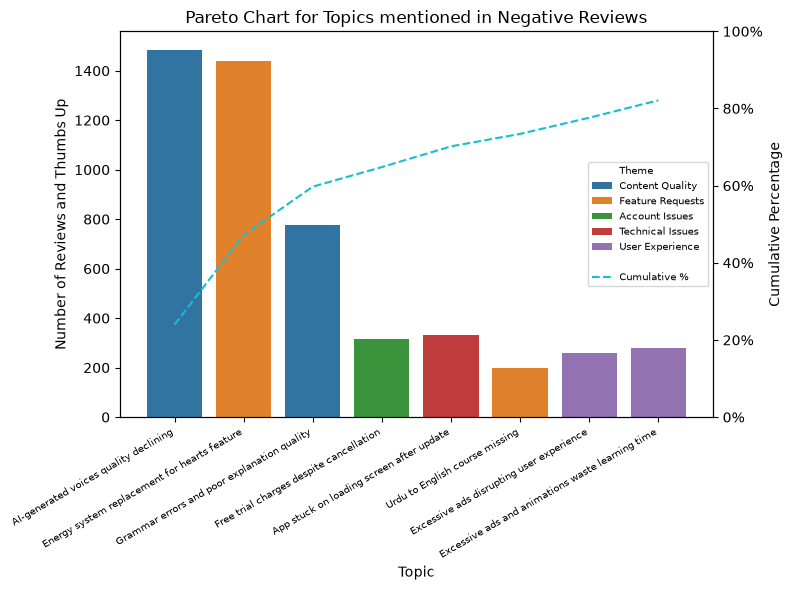

In [47]:
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.lines import Line2D

top_topics = topic_table[topic_table['CumulativePercentage'] <= cutoff]

fig, ax1 = plt.subplots(figsize=(8, 6))

sns.barplot(data=top_topics, x='Claude', y='thumbsAndReviews', hue='Theme', ax=ax1)
ax1.set_ylabel('Number of Reviews and Thumbs Up')
ax1.set_xlabel('Topic')
plt.xticks(rotation=30, ha='right', fontsize=7)

ax2 = ax1.twinx()
top_topics.plot.line(
    x='Claude', y='CumulativePercentage',
    linestyle='--', ax=ax2, color='C9', label='Cumulative %'
)
ax2.set_ylim(0, 1)
ax2.set_ylabel('Cumulative Percentage')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Combined legend on ax1
separator = Line2D([0], [0], color='none')

bar_handles, bar_labels = ax1.get_legend_handles_labels()
line_handles, line_labels = ax2.get_legend_handles_labels()

ax1.legend(
    handles=[separator]+bar_handles + [separator] + line_handles,
    labels=['Theme']+bar_labels +[''] +line_labels,
    loc='center right',
    fontsize=7
)
if ax2.get_legend():
    ax2.get_legend().remove()

plt.title('Pareto Chart for Topics mentioned in Negative Reviews')
plt.tight_layout()
plt.show()

Excessive ads disrupting user experience  and the one after are very similar... To be looked into further

In [48]:
theme_table = (topic_table.groupby('Theme').agg(
    numTopics=('Theme', 'count'),
    numReviews=('numReviews', 'sum'),
    numThumbsUp=('numThumbsUp', 'sum'),
    avgRating=('avgRating', 'mean')
))

theme_table['percentReviews'] = theme_table.numReviews / theme_table.numReviews.sum()
theme_table['percentThumbsUp'] = theme_table.numThumbsUp / theme_table.numThumbsUp.sum()
theme_table

,numTopics,numReviews,numThumbsUp,avgRating,percentReviews,percentThumbsUp
Theme,,,,,,
Account Issues,2,191,302,1.223990,0.077927,0.040299
Content Quality,5,857,3173,1.674261,0.349653,0.423405
Feature Requests,4,475,2439,2.005071,0.193798,0.325460
Technical Issues,7,498,649,1.785427,0.203182,0.086603
User Experience,6,430,931,1.871035,0.175439,0.124233
